## 설치·인증·공통 함수



In [1]:
%%capture
%pip install qiskit qiskit-ibm-runtime qiskit-aer pylatexenc


In [2]:

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeManilaV2   # 기본 fake backend

from google.colab import userdata

# Colab Secrets에 IBM Quantum Platform API 토큰을 IBM_QUANTUM_TOKEN으로 저장해 두세요.
ibm_token = userdata.get('IBM_TOKEN')

SHOTS = 100


def build_bell():
    """Bell 상태 회로 생성 (Sampler는 측정이 반드시 포함되어야 함)."""
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure_all()            # 고전 레지스터 이름이 'meas'로 생성됨
    return qc


def run_sampler(backend, qc, shots=SHOTS):
    """주어진 backend(실기 또는 fake)에 ISA 트랜스파일 후 SamplerV2로 실행.

    반환: {bitstring: count} 딕셔너리
    """
    # 각 backend의 명령어 집합(ISA)에 맞게 트랜스파일
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_qc = pm.run(qc)

    sampler = Sampler(mode=backend)
    result = sampler.run([isa_qc], shots=shots).result()

    # measure_all() → 레지스터 'meas'
    return result[0].data.meas.get_counts()


def plot_counts(counts, title):
    """counts를 막대그래프로 시각화하고, 각 막대 위에 숫자를 표기."""
    labels = sorted(counts)
    values = [counts[k] for k in labels]
    fig, ax = plt.subplots()
    bars = ax.bar(labels, values)
    ax.bar_label(bars, padding=2)      # 막대 위 숫자 표기
    ax.set_xlabel("bitstring")
    ax.set_ylabel("counts")
    ax.set_title(title)
    ax.margins(y=0.1)                  # 상단 라벨 잘림 방지
    plt.show()

## IBM 시뮬레이터(fake backend, 기본값) 먼저 실행

Fake simulator (fake_manila): {'11': 45, '00': 48, '10': 2, '01': 5}


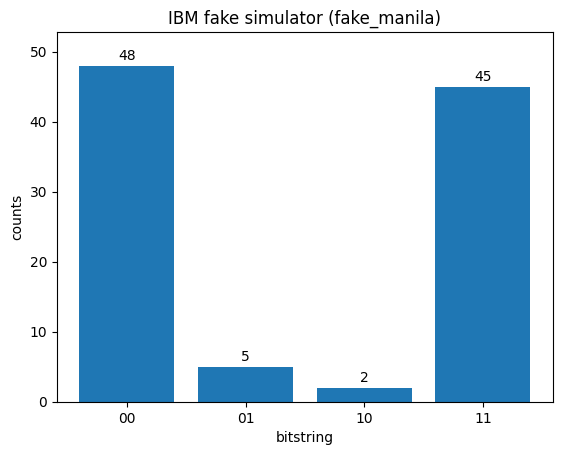

In [3]:
# 기본 fake backend. 인증 없이 로컬에서 동작합니다.
# (더 큰 장비 모사가 필요하면 FakeBrisbane 등으로 교체 가능)
fake_backend = FakeManilaV2()

qc = build_bell()

# 회로도 (실행/과금 없음)
qc.draw("mpl")
plt.show()

# 시뮬레이터 실행 + 결과 시각화 (이 셀만으로 완결)
sim_counts = run_sampler(fake_backend, qc)
print(f"Fake simulator ({fake_backend.name}):", sim_counts)
plot_counts(sim_counts, f"IBM fake simulator ({fake_backend.name})")

## 실기 QPU 큐 상태 확인 및 가장 빈 backend 선택

In [4]:
# 실기 접근을 위한 서비스 초기화 (ibm_quantum_platform이 기본 채널)
# 인스턴스 에러가 나면 instance="<CRN 또는 인스턴스명>"을 추가하세요.
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=ibm_token)


def show_and_pick_backend(service, min_qubits=2):
    """가동 중인 실기 QPU들의 대기 job 수를 표로 출력하고,
    큐가 가장 짧은(=가장 비어 있는) backend를 선택한다."""
    backends = service.backends(
        operational=True,      # 가동 중
        simulator=False,       # 실기만
        min_num_qubits=min_qubits,
    )
    if not backends:
        raise RuntimeError("사용 가능한 실기 backend가 없습니다.")

    print(f"{'backend':22} {'qubits':>7} {'pending_jobs':>13} {'operational':>12}")
    print("-" * 58)
    rows = []
    for b in backends:
        st = b.status()                    # 실시간 상태 조회
        rows.append((b, st.pending_jobs))
        print(f"{b.name:22} {b.num_qubits:>7} "
              f"{st.pending_jobs:>13} {str(st.operational):>12}")

    # pending_jobs가 가장 적은 backend 선택
    best = min(rows, key=lambda r: r[1])[0]
    print(f"\n>>> 선택된 실기 QPU: {best.name} "
          f"(pending_jobs={best.status().pending_jobs}, {best.num_qubits} qubits)")
    return best


real_backend = show_and_pick_backend(service)

qiskit_runtime_service._discover_account:WARNING:2026-07-22 15:20:48,659: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-22 15:20:52,480: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-22 15:20:52,482: Loading instance: open-instance, plan: open


backend                 qubits  pending_jobs  operational
----------------------------------------------------------
ibm_fez                    156             0         True
ibm_marrakesh              156             0         True
ibm_kingston               156             7         True

>>> 선택된 실기 QPU: ibm_fez (pending_jobs=0, 156 qubits)


## 실기 QPU 실행 및 시각화 (시뮬레이터 이후)

Real QPU (ibm_fez): {'00': 50, '11': 44, '01': 3, '10': 3}


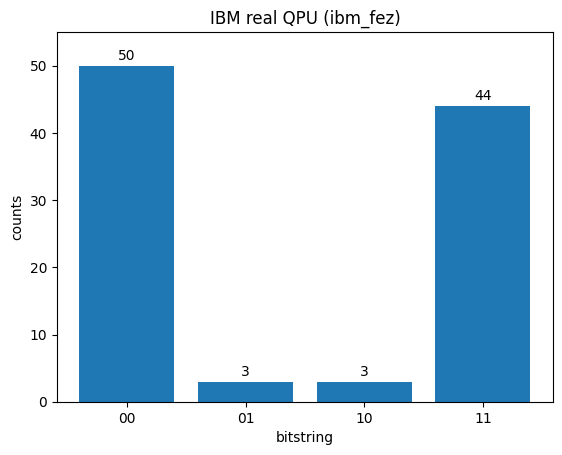

In [5]:
# 주의: 아래 실행은 실제 IBM QPU에 job을 제출합니다.
#       → 큐 대기가 발생하고, Open 플랜의 경우 무료 사용 시간이 소모됩니다.
qc = build_bell()
real_counts = run_sampler(real_backend, qc)
print(f"Real QPU ({real_backend.name}):", real_counts)
plot_counts(real_counts, f"IBM real QPU ({real_backend.name})")

## 시뮬레이터 vs 실기 비교 (막대에 숫자 표기)

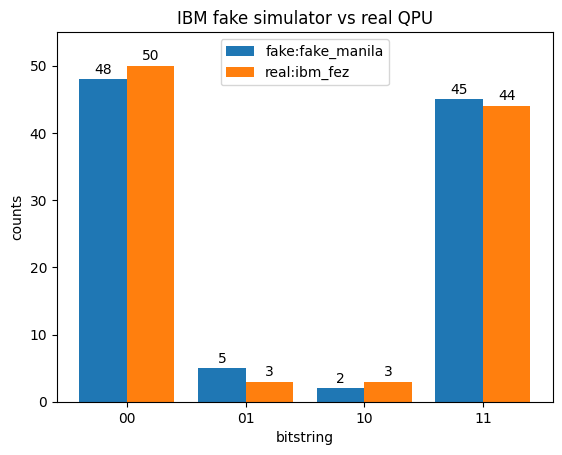

In [6]:
all_labels = sorted(set(sim_counts) | set(real_counts))
sim_vals = [sim_counts.get(k, 0) for k in all_labels]
real_vals = [real_counts.get(k, 0) for k in all_labels]

x = range(len(all_labels))
w = 0.4
fig, ax = plt.subplots()
bars_sim = ax.bar([i - w/2 for i in x], sim_vals, width=w,
                  label=f"fake:{fake_backend.name}")
bars_real = ax.bar([i + w/2 for i in x], real_vals, width=w,
                   label=f"real:{real_backend.name}")

ax.bar_label(bars_sim, padding=2)
ax.bar_label(bars_real, padding=2)

ax.set_xticks(list(x))
ax.set_xticklabels(all_labels)
ax.set_xlabel("bitstring")
ax.set_ylabel("counts")
ax.set_title("IBM fake simulator vs real QPU")
ax.legend()
ax.margins(y=0.1)
plt.show()